# 11-GraphRAG Foundations

In Lesson 10, we pushed standard vector retrieval to its structural limits. By deploying Parent-Child routing and Auto-Merging Trees, we broke the Chunk Size Paradox, delivering both high-precision retrieval and massive generative context.

But even with hierarchical routing, our architecture suffers from a catastrophic logical blind spot: **Multi-Hop Reasoning**.

Standard Vector Databases (and even Hybrid BM25 systems) retrieve documents based purely on *similarity to the query*. But what if the answer to the user's question requires connecting the dots across three completely different documents that share zero semantic similarity with each other?

To solve this, we must move beyond the probabilistic geometry of embedding vectors and introduce strict, deterministic mathematical networks: **Knowledge Graphs**. The fusion of these structures is known as **GraphRAG**.

Let's set up our environment to engineer graph-based retrieval physics.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & GraphRAG Environment Ready.")

/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


✅ Systems Architecture & GraphRAG Environment Ready.


# 1. The Multi-Hop Blind Spot

Let's examine a classic multi-hop query:
**"Who is the CEO of the company that acquired Project Quantum?"**

Suppose our Enterprise database contains two separate documents:

* **Document A**: *"In Q3, Project Quantum was fully acquired by Nexus Dynamics."*
* **Document B**: *"Sarah Jenkins has been appointed as the new CEO of Nexus Dynamics."*

**The Vector DB Failure**: The user's query embeds into a dense vector space heavily weighted toward "CEO" and "Project Quantum". It will likely retrieve Document A. However, Document A does not contain the answer. Document B contains the answer, but because Document B never mentions "Project Quantum", its Cosine Similarity to the query is nearly zero. Document B is never retrieved. The LLM hallucinates.

# 2. The Mathematics of Knowledge Graphs

To solve this, GraphRAG dictates that during the **Indexing Phase** (before the user ever asks a question), we pass every single text chunk through an LLM to extract a deterministic **Knowledge Graph**.

A Knowledge Graph $G$ is defined as a set of Vertices (Entities) $V$ and Edges (Relationships) $E$:


$$G = (V, E)$$

The LLM extracts information as **Semantic Triplets**:


$$\langle e_{head}, r, e_{tail} \rangle$$


*Example: $\langle \text{Project Quantum}, \text{acquired\_by}, \text{Nexus Dynamics} \rangle$*

When the user asks the multi-hop question, we do not just rely on vector similarity. We perform a **Graph Traversal**. We locate "Project Quantum" in the graph, traverse the outgoing edge to "Nexus Dynamics", and traverse the outgoing edge to "Sarah Jenkins". We extract this exact sub-graph and pass it to the LLM.

# 3. Architecting the GraphRAG Engine

Let's build a functional GraphRAG routing engine using Python's `networkx` library. We will simulate the LLM triplet extraction, construct the multi-hop network, and execute a graph traversal retrieval.

In [2]:
# --- 🕸️ The GraphRAG Traversal Engine ---

class GraphRAGIndex:
    def __init__(self):
        # Initialize a directed graph
        self.graph = nx.DiGraph()
        
    def ingest_triplets(self, triplets: list[tuple[str, str, str]]):
        """Populates the Knowledge Graph with extracted entities and relationships."""
        for head, relation, tail in triplets:
            self.graph.add_edge(head, tail, label=relation)
            
    def retrieve_subgraph(self, starting_entity: str, max_depth: int = 2) -> str:
        """
        Executes a Breadth-First Search (BFS) to retrieve a localized sub-graph 
        around the target entity to serve as LLM context.
        """
        if starting_entity not in self.graph:
            return "Entity not found in Knowledge Graph."
            
        print(f"🕸️ [GRAPH ROUTER] Initiating {max_depth}-Hop Traversal from '{starting_entity}'...")
        
        # Isolate the neighborhood up to max_depth hops
        subgraph_nodes = nx.single_source_shortest_path_length(self.graph, starting_entity, cutoff=max_depth)
        subgraph = self.graph.subgraph(subgraph_nodes)
        
        # Serialize the sub-graph into a text prompt for the LLM
        context_lines = []
        for u, v, data in subgraph.edges(data=True):
            relation = data['label']
            context_lines.append(f"- {u} [{relation}] {v}")
            
        return "\n".join(context_lines)

# 1. Simulate the LLM Extraction Phase (Done offline during document ingestion)
extracted_enterprise_triplets = [
    # Document A content
    ("Project Quantum", "acquired_by", "Nexus Dynamics"),
    ("Project Quantum", "budget_status", "Over Budget"),
    
    # Document B content
    ("Nexus Dynamics", "has_CEO", "Sarah Jenkins"),
    ("Nexus Dynamics", "headquarters", "Seattle"),
    
    # Document C content
    ("Sarah Jenkins", "former_role", "CTO of CyberDyne")
]

# 2. Build the Index
kg_index = GraphRAGIndex()
kg_index.ingest_triplets(extracted_enterprise_triplets)

# 3. Execute the Multi-Hop Query
user_query = "Who is the CEO of the company that acquired Project Quantum, and where did she work previously?"

# We use standard NER (Named Entity Recognition) to pull the starting node from the query
starting_node = "Project Quantum" 

print(f"\n--- 🔍 Resolving Multi-Hop Query ---")
print(f"User Query: '{user_query}'")

# Execute a 3-Hop Traversal to connect all the dots
graph_context = kg_index.retrieve_subgraph(starting_node, max_depth=3)

print(f"\n--- 📝 Context Injected into LLM Prompt ---")
print(graph_context)

print("\n--- 💡 Engineering Insight ---")
print("Look at the retrieved context! A standard Vector DB would have failed because 'CyberDyne' and 'Project Quantum' share zero semantic similarity. But the GraphRAG engine physically walked the mathematical bridge: Quantum -> Nexus -> Jenkins -> CyberDyne. The LLM now has 100% of the facts required to generate a perfect answer.")


--- 🔍 Resolving Multi-Hop Query ---
User Query: 'Who is the CEO of the company that acquired Project Quantum, and where did she work previously?'
🕸️ [GRAPH ROUTER] Initiating 3-Hop Traversal from 'Project Quantum'...

--- 📝 Context Injected into LLM Prompt ---
- Project Quantum [acquired_by] Nexus Dynamics
- Project Quantum [budget_status] Over Budget
- Nexus Dynamics [has_CEO] Sarah Jenkins
- Nexus Dynamics [headquarters] Seattle
- Sarah Jenkins [former_role] CTO of CyberDyne

--- 💡 Engineering Insight ---
Look at the retrieved context! A standard Vector DB would have failed because 'CyberDyne' and 'Project Quantum' share zero semantic similarity. But the GraphRAG engine physically walked the mathematical bridge: Quantum -> Nexus -> Jenkins -> CyberDyne. The LLM now has 100% of the facts required to generate a perfect answer.


# 4. Visualizing the Multi-Hop Topology

To mathematically prove why graph structures solve the isolated document problem, let's visualize the exact sub-graph we just traversed. We will plot the nodes, draw the directional edges, and highlight the exact multi-hop pathway the algorithm took to reach the answer.

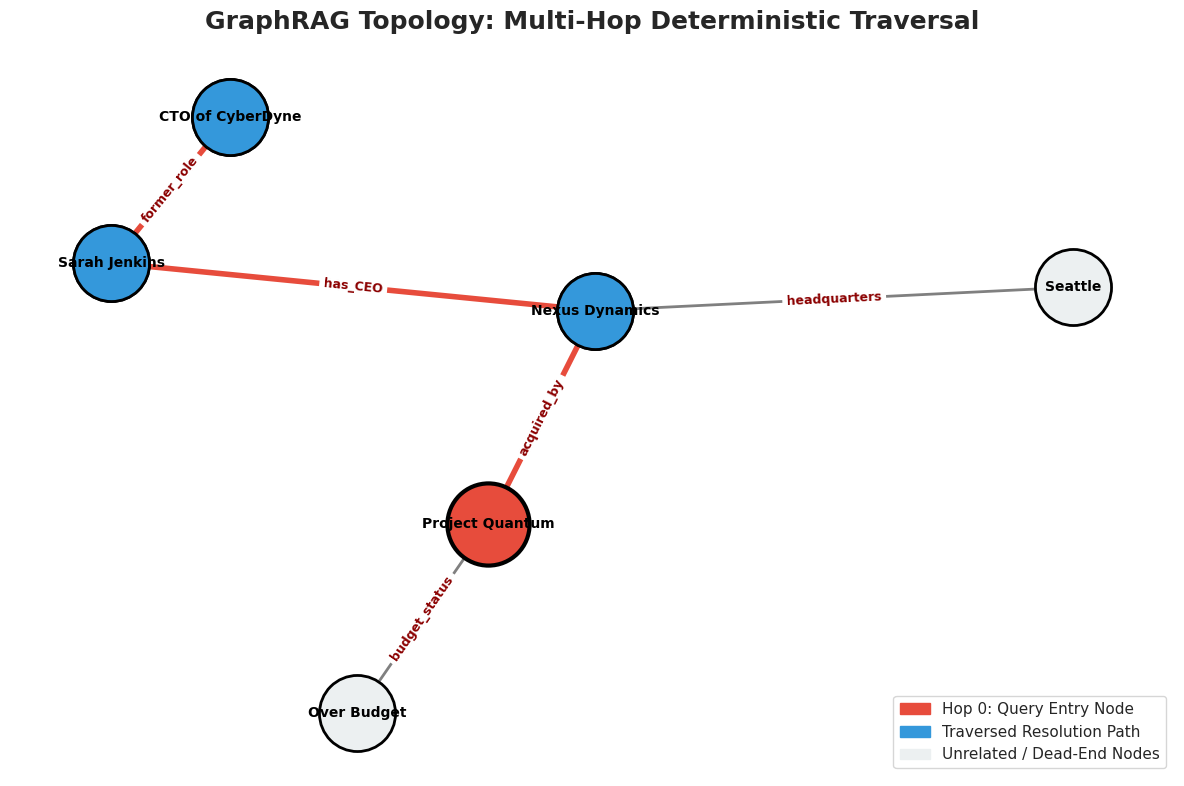

In [3]:
# Visualizing the Knowledge Graph Topology
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("GraphRAG Topology: Multi-Hop Deterministic Traversal", fontsize=18, fontweight='bold')

ax.axis('off')

# Use a spring layout to position the nodes automatically based on connections
pos = nx.spring_layout(kg_index.graph, seed=42, k=0.9)

# Draw all nodes (Base structure)
nx.draw_networkx_nodes(kg_index.graph, pos, ax=ax, node_color='#ecf0f1', node_size=3000, edgecolors='black', linewidths=2)

# Highlight the Primary Path (The 3-Hop Resolution)
path_nodes = ["Project Quantum", "Nexus Dynamics", "Sarah Jenkins", "CTO of CyberDyne"]
nx.draw_networkx_nodes(kg_index.graph, pos, ax=ax, nodelist=path_nodes, node_color='#3498db', node_size=3000, edgecolors='black', linewidths=2)

# Highlight the Entry Node
nx.draw_networkx_nodes(kg_index.graph, pos, ax=ax, nodelist=["Project Quantum"], node_color='#e74c3c', node_size=3500, edgecolors='black', linewidths=3)

# Draw all edges
nx.draw_networkx_edges(kg_index.graph, pos, ax=ax, edge_color='gray', arrows=True, arrowsize=20, width=2)

# Highlight the specific traversal edges
path_edges = [("Project Quantum", "Nexus Dynamics"), ("Nexus Dynamics", "Sarah Jenkins"), ("Sarah Jenkins", "CTO of CyberDyne")]
nx.draw_networkx_edges(kg_index.graph, pos, ax=ax, edgelist=path_edges, edge_color='#e74c3c', arrows=True, arrowsize=25, width=4)

# Draw Node Labels
nx.draw_networkx_labels(kg_index.graph, pos, ax=ax, font_size=10, font_weight='bold', font_color='black')

# Draw Edge Labels (The Relational Predicates)
edge_labels = nx.get_edge_attributes(kg_index.graph, 'label')
nx.draw_networkx_edge_labels(kg_index.graph, pos, edge_labels=edge_labels, ax=ax, font_size=9, font_color='darkred', font_weight='bold', label_pos=0.5)

# Add Legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#e74c3c', label='Hop 0: Query Entry Node')
blue_patch = mpatches.Patch(color='#3498db', label='Traversed Resolution Path')
gray_patch = mpatches.Patch(color='#ecf0f1', label='Unrelated / Dead-End Nodes')
ax.legend(handles=[red_patch, blue_patch, gray_patch], loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of GraphRAG like a **Police Detective's Stringboard**:

* **Standard Vector RAG (The File Cabinet)**: A detective wants to know if Suspect A is connected to the bank robbery. They go to the filing cabinet (The Vector DB) and search for files containing the words "Suspect A" and "Bank Robbery". They find nothing. The files are isolated. The investigation fails.
* **GraphRAG (The Stringboard)**: Before the case even begins, the detective reads every single case file in the precinct and pins photos to a corkboard, connecting them with red string (The Knowledge Graph).
* When asked about Suspect A, the detective looks at the board. They start at Suspect A's photo. They follow a red string to a *License Plate*. They follow a string from the License Plate to a *Rental Car Company*. They follow a string from the Rental Car Company to the *Bank Robbery*. By traversing the physical strings (Edges), the detective uncovers the multi-hop truth that isolated keyword searches could never find.